# ATiG 2026: LT-FH exercise using ltpred

*Worked answers.* Each answer follows its question; code cells are filled in.

## What you will learn

You score a simulated register with [ltpred](https://github.com/bvilhjal/ltpred)'s
family-history method and compare the scores with the true genetic liability, which a
simulation lets you see. Five parts, 15 questions:

- **A** (in class). A wrong heritability h² rescales the score but barely changes its ranking.
- **B** (in class). The score is a posterior mean, not a risk: predicting later diagnosis.
- **C** (homework). The score against a simple 0/1 family-history indicator.
- **D** (homework). Estimating h² from parent–offspring pairs, and how a case-enriched sample breaks it.
- **E** (homework). Observed-scale versus liability-scale h².

Before each part, write down what you expect. Q15 asks for a short note on what you found.

**Background.** LT-FH ([Hujoel et al. 2020](https://doi.org/10.1038/s41588-020-0613-6))
turns relatives' diagnoses into an estimate of a person's genetic liability;
LT-FH++ ([Pedersen et al. 2022](https://doi.org/10.1016/j.ajhg.2022.01.009)) adds age of
onset. ltpred computes it with the Pearson–Aitken method of PA-FGRS
([Krebs et al. 2024](https://doi.org/10.1016/j.ajhg.2024.09.009)). The model is on the
[algorithm page](https://bvilhjal.github.io/ltpred/algorithm/).

## How to use this notebook

- Run the cells from top to bottom. Part 0 builds everything the questions use.
- **Your cells contain `...`.** Replace each `...` with one expression; the comment
  next to it says what. Every other line runs as given.
- **Checkpoints** say what you should see, so you know you are on track.

The names you will use throughout:

| Name | What it is |
|---|---|
| `reg` | the simulated register (one row per person) |
| `g` | each person's true genetic liability |
| `est`, `var` | everyone's score and its posterior variance, using all records |
| `free40` | True for people still undiagnosed at 40 |
| `est40`, `var40` | the score as known at 40, for those people |
| `score(h2)`, `score_at_40(h2)` | rescore the register under any assumed h² |

## Setup

Install Python, NumPy, SciPy and ltpred from the
[setup page](https://bvilhjal.github.io/ATIG_2026/setup.html) (macOS, Windows or Anaconda),
then run the cell below. It also defines two small helpers, `corr` and `auc`. The whole
notebook runs in under a minute with less than 1 GB of memory.

In [1]:
import numpy as np
from scipy.stats import norm, rankdata

import ltpred
from ltpred import simulate_pedigree, simulate_register_liabilities, estimate_liabilities
print("ltpred", ltpred.__version__)


def corr(x, y):
    """Pearson correlation of two arrays."""
    return np.corrcoef(x, y)[0, 1]


def auc(score, case):
    """AUC: the chance that a random case scores above a random non-case.

    Computed from ranks (the Mann-Whitney statistic); `case` is a boolean array."""
    r = rankdata(score)
    n1, n0 = case.sum(), (~case).sum()
    return (r[case].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

ltpred 0.7.1


## Part 0. A register where the truth is known

The cell below simulates three generations of families (5,075 people) and gives each
person a liability: a genetic part `g` with variance h² = 0.5 plus a non-genetic part.
A person is diagnosed at the age their liability crosses an age-dependent threshold, so
high liability means early onset. Everyone is followed to age 70. This is the model of
the [ltpred tutorial](https://bvilhjal.github.io/ltpred/tutorial/), five times larger.

`reg` holds what a real register would, plus the truth:

| Field | Meaning |
|---|---|
| `reg.ids`, `reg.father`, `reg.mother` | the pedigree |
| `reg.status` | diagnosed by age 70 (True/False) |
| `reg.age` | age at diagnosis, or 70 for the undiagnosed |
| `reg.onset`, `reg.birth_time` | age at onset (`inf` if never) and calendar time of birth |
| `reg.genetic` | the true genetic liability, stored as `g` |

In [2]:
H2 = 0.5                                    # true liability-scale heritability
K = 0.10                                    # lifetime prevalence
AGES = np.arange(0, 121.0)                  # ages 0, 1, ..., 120
CIP = K / (1 + np.exp((60 - AGES) / 8))     # cumulative incidence by age: half of K by age 60

ids, father, mother = simulate_pedigree(np.random.default_rng(1), n_founder_pairs=500, gens=2)
reg = simulate_register_liabilities(np.random.default_rng(1), ids, father, mother,
                                    h2=H2, cip_ages=AGES, cip_values=CIP, eval_age=70)
g = reg.genetic                             # the truth, known only because we simulated it

print(f"{len(reg.ids)} people, {reg.status.sum()} diagnosed by age 70 ({reg.status.mean():.1%})")
print(f"var(g) = {g.var():.3f}   (target {H2})")

5075 people, 366 diagnosed by age 70 (7.2%)
var(g) = 0.493   (target 0.5)


**Checkpoint.** 5,075 people, 366 diagnosed (7.2%), and var(g) close to 0.5.

### The scorer in one call

`estimate_liabilities` takes the pedigree, everyone's diagnosis and age, the incidence
curve and h², and returns for each proband the **posterior mean** of their genetic
liability given the relatives' records (`.est`), with its **posterior variance**
(`.var`). The comments explain each argument.

In [3]:
scores = estimate_liabilities(
    reg.ids, reg.father, reg.mother,          # the pedigree: who is whose parent
    probands=reg.ids,                         # whom to score: everyone
    status=reg.status, age=reg.age,           # diagnosed by 70? age at diagnosis or at 70
    cip_ages=AGES, cip_values=CIP, k_pop=K,   # incidence curve: turns an age into a liability threshold
    h2=H2,                                    # heritability: you supply it, the scorer never estimates it
    use="gwas")                               # also use each person's own diagnosis

est, var = scores.est, scores.var
print(f"corr(score, g) = {corr(est, g):.3f}")
print(f"var(score) = {est.var():.3f}  +  mean posterior variance = {var.mean():.3f}"
      f"  =  {est.var() + var.mean():.3f}")

corr(score, g) = 0.522
var(score) = 0.129  +  mean posterior variance = 0.359  =  0.488


**Checkpoint.** Correlation 0.522. The variance of the scores plus the average posterior
variance comes back to about var(g): the data explain part of each person's genetic
liability and the posterior variance holds the rest. Part A asks what happens to this
sum when h² is wrong.

### Two helpers used in every question

`score(h2)` repeats the call above under any assumed h². `score_at_40(h2)` scores the
people still undiagnosed at 40 **as of their 40th birthday**: `use="prediction"` hides
their own status and every record made after that date. This is the honest setting for
predicting who is diagnosed later.

In [4]:
free40 = reg.onset > 40                     # still undiagnosed on their 40th birthday


def score(h2):
    """Everyone's score from all records up to 70 (use="gwas"): (mean, variance)."""
    s = estimate_liabilities(reg.ids, reg.father, reg.mother, probands=reg.ids,
                             status=reg.status, age=reg.age,
                             cip_ages=AGES, cip_values=CIP, k_pop=K, h2=h2, use="gwas")
    return s.est, s.var


def score_at_40(h2):
    """Scores as known on each person's 40th birthday (use="prediction"), for the
    people still undiagnosed then: their own status and every later record are hidden."""
    s = estimate_liabilities(reg.ids, reg.father, reg.mother,
                             probands=[p for p, keep in zip(reg.ids, free40) if keep],
                             status=reg.status, age=reg.age,
                             cip_ages=AGES, cip_values=CIP, k_pop=K, h2=h2, use="prediction",
                             birth_time=reg.birth_time,                  # everyone's birth date
                             index_time=(reg.birth_time + 40)[free40])   # each proband's 40th birthday
    return s.est, s.var


est40, var40 = score_at_40(H2)
print(f"{free40.sum()} people undiagnosed at 40; corr(score at 40, g) = {corr(est40, g[free40]):.3f}")

5037 people undiagnosed at 40; corr(score at 40, g) = 0.278


**Checkpoint.** 5,037 people are undiagnosed at 40, and their score at 40 correlates
0.278 with `g`: weaker than 0.522, because it knows less.

## Part A. What does a wrong h² do?

In a real analysis h² comes from outside (a twin, pedigree or SNP study), on the
liability scale, and ltpred makes you supply it. Here you can pass a wrong value on
purpose and compare with the truth.

### Q1: If you tell the scorer h² = 0.8 when the truth is 0.5, do the scores spread more or less? Does their ranking change?

Write your expectation with one sentence of reasoning. Hint: h² is the share of
liability variance that is genetic, and therefore shared with relatives.

**Answer.** With h² = 0.8 the scorer believes relatives, and a person's own diagnosis,
say more about their genetic liability than they do, so every score moves further from
zero: the spread grows. The ranking barely changes, because the same records point the
same way; only their weight changes. Q2 checks both claims.

### Q2: Score the register under h² = 0.2, 0.5 and 0.8.

For each value the loop prints the correlation with `g`, the variance of the scores, the
mean posterior variance, their sum, and the **calibration slope**: the slope of `g`
regressed on the score. Fill in the two `...`.

In [5]:
by_h2 = {}                                   # kept for the figure below
print("assumed h2   corr  var(score)  mean var    sum  slope")
for h2 in (0.2, 0.5, 0.8):
    e, v = score(h2)
    c = corr(e, g)
    b = np.polyfit(e, g, 1)[0]
    by_h2[h2] = e
    print(f"{h2:10.1f} {c:6.3f} {e.var():10.3f} {v.mean():9.3f} {e.var() + v.mean():6.3f} {b:6.2f}")

assumed h2   corr  var(score)  mean var    sum  slope


       0.2  0.515      0.031     0.172  0.203   2.06


       0.5  0.522      0.129     0.359  0.488   1.02


       0.8  0.519      0.270     0.487  0.756   0.70


**Answer.** The correlation is 0.515, 0.522 and 0.519: the ranking hardly notices. The
variance columns follow the assumed value instead of the truth: the sum reads 0.20, 0.49
and 0.76, the h² the scorer was told, not the 0.5 that generated the data. The slope is
2.06, 1.02 and 0.70. In the figure only the middle panel's blue line lies on the dashed diagonal (slope 1).

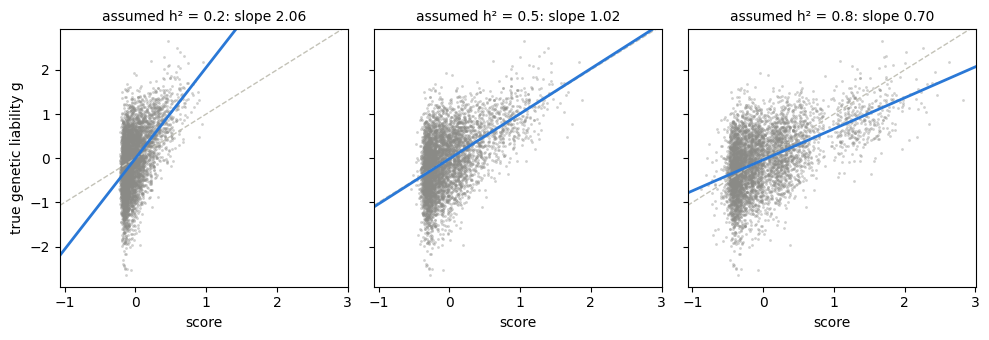

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharex=True, sharey=True)
for ax, (h2, e) in zip(axes, by_h2.items()):
    b, a = np.polyfit(e, g, 1)
    ax.scatter(e, g, s=4, color="#8a8a86", alpha=0.4, linewidths=0)
    ax.axline((0, 0), slope=1, color="#c3c2b7", ls="--", lw=1)      # slope 1: calibrated
    ax.axline((0, a), slope=b, color="#2a78d6", lw=2)                # truth regressed on score
    ax.set_title(f"assumed h² = {h2}: slope {b:.2f}", fontsize=10)
    ax.set_xlabel("score")
axes[0].set_ylabel("true genetic liability g")
fig.tight_layout()

### Q3: Which columns moved and which did not? What does a slope of 1 mean, and why does only the right h² give it?

A score is *calibrated* when the truth regressed on it has slope 1: among people scored
0.3, the true liability averages 0.3.

**Answer.** The correlation stayed put; the variances, their sum and the slope moved. A
posterior mean is calibrated when the model behind it is the model that generated the
data, and only h² = 0.5 is. Under 0.2 the scores are too timid (the truth moves twice as
fast as the score); under 0.8 they are too bold.

A GWAS that uses the score as its phenotype only needs the ranking and survives a wrong
h². Anything that reads the score's scale does not: a risk (Part B), a comparison across
diseases, or the variance a polygenic score explains. That is why the h² you supply must
be a real liability-scale estimate, or cross-checked as in Part D.

## Part B. Who is diagnosed between 40 and 70?

![Liability thresholds at 40 and 70. Higher liability is earlier onset. People still undiagnosed at 40 are left of T40; those diagnosed by 70 have crossed T70.](figures/thresholds.png)

A correlation with `g` is not the accuracy of predicting a later diagnosis. Here you
measure that accuracy directly, using the score at 40 (`est40`) and what happened next.

### Q4: How many of the people undiagnosed at 40 are diagnosed by 70?

`reg.status` means "diagnosed by 70" and `free40` means "undiagnosed at 40". The result
`y` must line up with `est40`, which has one entry per person in `free40`.

In [7]:
y = reg.status[free40]       # everyone in est40 was undiagnosed at 40, so "by 70" means "40 to 70"
print(f"{y.sum()} incident cases among {len(y)} people ({y.mean():.1%})")

328 incident cases among 5037 people (6.5%)


**Answer.** 328 cases among 5,037 people, 6.5%. The 38 people diagnosed before 40 are
excluded: they were already cases at 40, so scoring them and calling it a prediction
would be leakage.

### Q5: Compute the AUC of three predictors of that outcome, on the same people.

The AUC is the chance that a random case scores above a random non-case (0.5 is a coin
flip, 1 is perfect). Compare: the score at 40, `est40`; the true genetic liability `g`,
the best any genetic predictor could do; and the `use="gwas"` score `est`, which saw each
person's own diagnosis. **Before running**, order the three.

In [8]:
print(f"AUC score at 40             {auc(est40, y):.3f}")
print(f"AUC true g                  {auc(g[free40], y):.3f}")
print(f"AUC use='gwas' score        {auc(est[free40], y):.3f}")

AUC score at 40             0.605
AUC true g                  0.887
AUC use='gwas' score        0.995


**Answer.** 0.995 for the `use="gwas"` score, 0.887 for the true `g`, 0.605 for the
score at 40. With 328 cases the standard errors are about 0.003, 0.012 and 0.017, so the
three are far apart.

### Q6: Why is even the truth below AUC 1? Why is the score at 40 so far below the truth? What does the third AUC say about using a `use="gwas"` score for prediction?

The cell below prints three variances that help.

In [9]:
print(f"var(g)                        {g.var():.3f}")
print(f"var(score), use='gwas'        {est.var():.3f}")
print(f"var(score at 40)              {est40.var():.3f}")

var(g)                        0.493
var(score), use='gwas'        0.129
var(score at 40)              0.040


**Answer.** Diagnosis depends on the full liability, genetic plus non-genetic, and the
non-genetic half (variance 1 − h² = 0.5) is invisible to any genetic predictor. So even
perfect knowledge of `g` reaches only 0.887.

The score at 40 knows `g` only through relatives' diagnoses made before that date. Its
variance, 0.040, is a small fraction of var(g) = 0.493: it captures little of `g`, and its
AUC is 0.605.

The third AUC, 0.995, is leakage. The `use="gwas"` score contains each person's own
diagnosis, which is the outcome, so the evaluation compares the outcome with itself.
Never use it to claim prediction.

### Q7: Turn the score at 40 into a risk and check it against what happened.

`est40` is not a probability. Given the relatives, a person's full liability is normal
with mean `est40` and standard deviation `sd = sqrt(var40 + 1 − h²)`. Being undiagnosed
at 40 means it is below the threshold T40; diagnosis by 70 means it is above T70. So

**risk = [P(below T40) − P(below T70)] / P(below T40)**,

where P(below T) = Φ((T − est40) / sd). The first lines compute T40, T70, `sd` and
P(below T40); write the risk. The loop then compares risk with the observed rate within
fifths of the score.

In [10]:
T40, T70 = norm.isf(np.interp([40, 70], AGES, CIP))   # liability thresholds at ages 40 and 70
sd = np.sqrt(var40 + 1 - H2)                          # spread of full liability given the relatives
below_T40 = norm.cdf((T40 - est40) / sd)              # P(liability < T40): undiagnosed at 40
risk = (below_T40 - norm.cdf((T70 - est40) / sd)) / below_T40

print(f"mean risk {risk.mean():.3f}   observed incidence {y.mean():.3f}")
fifths = np.array_split(np.argsort(est40, kind="stable"), 5)    # lowest to highest score
for name, idx in zip(("lowest", "second", "middle", "fourth", "highest"), fifths):
    print(f"{name:>8} fifth: {y[idx].sum():3d} cases, observed {y[idx].mean():.3f}, "
          f"risk {risk[idx].mean():.3f}")

mean risk 0.070   observed incidence 0.065
  lowest fifth:  44 cases, observed 0.044, risk 0.044
  second fifth:  52 cases, observed 0.052, risk 0.056
  middle fifth:  49 cases, observed 0.049, risk 0.062
  fourth fifth:  76 cases, observed 0.075, risk 0.070
 highest fifth: 107 cases, observed 0.106, risk 0.117


**Answer.** Mean risk 7.0% against 6.5% observed, within sampling error. By fifth the
observed rate is 4.4%, 5.2%, 4.9%, 7.5% and 10.6% against risks of 4.4%, 5.6%, 6.2%,
7.0% and 11.7%. Each fifth holds only 44 to 107 cases, so the error bars are 0.6 to 1.0
percentage points. The top fifth has 2.4 times the risk of the bottom one, and the middle
three are hard to tell apart: that is what an AUC of 0.6 looks like.

The risk needs `var40` because two people with the same score but different numbers of
informative relatives have different uncertainty, and more spread puts more probability
past the threshold. It also uses h² twice, so a wrong h² (Part A) gives a confidently
wrong risk.

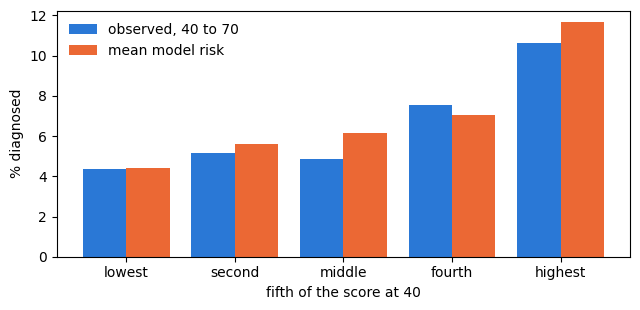

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
x = np.arange(5)
observed = [100 * y[idx].mean() for idx in fifths]
model = [100 * risk[idx].mean() for idx in fifths]
ax.bar(x - 0.2, observed, width=0.4, color="#2a78d6", label="observed, 40 to 70")
ax.bar(x + 0.2, model, width=0.4, color="#eb6834", label="mean model risk")
ax.set_xticks(x, ["lowest", "second", "middle", "fourth", "highest"])
ax.set_xlabel("fifth of the score at 40")
ax.set_ylabel("% diagnosed")
ax.legend(frameon=False)
fig.tight_layout()

## Part C. The score against a 0/1 family-history indicator (homework)

A common shortcut is the indicator "any parent or full sibling diagnosed". The cell below
finds each person's first-degree relatives (FDRs); run it as is.

In [12]:
row = {p: i for i, p in enumerate(reg.ids)}          # id -> row number
children = {}                                        # (father, mother) -> rows of their children
for i, (f, m) in enumerate(zip(reg.father, reg.mother)):
    if f in row and m in row:
        children.setdefault((f, m), []).append(i)


def first_degree(i):
    """Rows of person i's parents and full siblings."""
    f, m = reg.father[i], reg.mother[i]
    parents = [row[p] for p in (f, m) if p in row]
    siblings = [j for j in children.get((f, m), []) if j != i]
    return np.array(parents + siblings, dtype=int)


fdr = [first_degree(i) for i in range(len(reg.ids))]
diag_time = reg.birth_time + reg.onset               # calendar time of each diagnosis
birth40 = reg.birth_time + 40                        # calendar time of each 40th birthday

### Q8: How much does the score improve on the indicator?

With follow-up to 70, compare how much of `g` (R²) is explained by: own status, the 0/1
indicator, the number of affected FDRs, and the `use="gwas"` score. Then compare
prospectively, by AUC for the Part B outcome: a fair indicator counts a relative only if
they were diagnosed **by the person's 40th birthday**, that is `reg.status[r]` and
`diag_time[r] <= birth40[i]`. Why does own status not appear in the prospective part?

In [13]:
n_fdr = np.array([reg.status[r].sum() for r in fdr])          # affected relatives, follow-up to 70
n_fdr40 = np.array([(reg.status[r] & (diag_time[r] <= birth40[i])).sum()
                    for i, r in enumerate(fdr)])              # affected by person i's 40th birthday
fh, fh40 = n_fdr > 0, n_fdr40 > 0                             # the 0/1 indicators

for name, x in (("own status", reg.status), ("FH indicator 0/1", fh),
                ("# affected FDRs", n_fdr), ("use='gwas' score", est)):
    print(f"R2  {name:22s} {corr(x, g) ** 2:.3f}")
for name, x in (("FH indicator 0/1 at 40", fh40[free40]),
                ("# affected FDRs at 40", n_fdr40[free40]), ("score at 40", est40)):
    print(f"AUC {name:22s} {auc(x, y):.3f}")
print(f"FH-positive: {fh.sum()} with follow-up to 70, {fh40.sum()} at their 40th birthday")

R2  own status             0.145


R2  FH indicator 0/1       0.068
R2  # affected FDRs        0.075
R2  use='gwas' score       0.273


AUC FH indicator 0/1 at 40 0.562
AUC # affected FDRs at 40  0.563
AUC score at 40            0.605
FH-positive: 954 with follow-up to 70, 609 at their 40th birthday


**Answer.** With follow-up to 70 the indicator explains 6.8% of the variance of `g`, the
count 7.5%, own status 14.5% and the `use="gwas"` score 27.3%: four times the indicator,
because it also weighs each relative's age and type and the person's own diagnosis.
Prospectively own status is the same for everyone (all were undiagnosed at 40), and the
AUCs are 0.562 for the indicator, 0.563 for the count and 0.605 for the score. Only 609
people are FH-positive at 40, against 954 by 70.

## Part D. Where does h² come from? (homework)

Part A showed that h² matters. A quick cross-check: h² is about twice the **tetrachoric
correlation** between parents' and children's diagnoses, the correlation of the
underlying liabilities inferred from a 2×2 table. The cell below lists every
parent–child pair as row numbers `par` and `kid` and defines `table`; run it as is.

In [14]:
from ltpred import tetrachoric, tetrachoric_table

# every parent-child pair in the register, as row numbers
pairs = [(row[p], i) for i, (f, m) in enumerate(zip(reg.father, reg.mother))
         for p in (f, m) if p in row]
par, kid = np.array(pairs).T


def table(a, b, w=1):
    """2x2 table of two boolean arrays: both, first only, second only, neither.
    Optional weights w count each pair w times."""
    return np.array([(w * (a & b)).sum(), (w * (a & ~b)).sum(),
                     (w * (~a & b)).sum(), (w * (~a & ~b)).sum()])

### Q9: Estimate h² from the parent–offspring pairs.

In [15]:
p_status, k_status = reg.status[par], reg.status[kid]
t = tetrachoric(p_status, k_status)
print(f"{len(par)} pairs, table {table(p_status, k_status)}")
print(f"h2 = 2 rho = {2 * t.rho:.2f} +/- {2 * t.se:.2f}   (truth {H2})")

7884 pairs, table [  90  489  460 6845]
h2 = 2 rho = 0.52 +/- 0.07   (truth 0.5)


**Answer.** h² = 0.52 ± 0.07 from 7,884 pairs. Almost all the information is in the 90
pairs where both are diagnosed. Standard errors shrink with the square root of the number
of pairs: the tutorial's register, a fifth of this size, gives 0.47 ± 0.15.

### Q10: Why does twice the tetrachoric work here, and what would break it in a real register?

Think about the threshold, shared environment, and how the register was sampled.

**Answer.** It works when (1) everyone's status is cut at one common threshold, true here
because everyone is followed to 70; (2) the parent–offspring liability covariance is h²/2
and nothing else, true because this simulation has no shared environment; and (3) the
pairs are a population sample.

Real registers break (1) first: people are followed to different ages and born in
different years, so one status column mixes thresholds. That is what the age-specific
thresholds of LT-FH++ fix. Shared environment inflates the estimate. Q11 breaks (3).

### Q11: Repeat the estimate on a case-enriched sample.

Many registers are case-enriched: iPSYCH, for example, holds every case in its birth
cohorts plus a random sample of everyone else. Keep every case and each non-case with
probability 0.2, then estimate h² from the sampled pairs. Then undo the design: a pair
stands for 1 / (π_parent · π_child) population pairs, where π is each person's chance of
being sampled (1 for cases, 0.2 otherwise). Fill in the case rate and the weights.

In [16]:
keep = reg.status | (np.random.default_rng(20260924).random(len(reg.ids)) < 0.2)   # the sample
pi = np.where(reg.status, 1.0, 0.2)                    # each person's chance of being sampled
both = keep[par] & keep[kid]                           # pairs with parent and child both sampled
p_s, k_s = reg.status[par[both]], reg.status[kid[both]]
print(f"sampled {keep.sum()} of {len(keep)}: case rate {reg.status[keep].mean():.1%} vs {reg.status.mean():.1%}")

naive = tetrachoric(p_s, k_s)
print(f"{both.sum()} pairs, table {table(p_s, k_s)} -> naive h2 = {2 * naive.rho:.2f} +/- {2 * naive.se:.2f}")

w = 1 / (pi[par[both]] * pi[kid[both]])               # each pair's weight 1 / (pi_parent * pi_child)
weighted = np.round(table(p_s, k_s, w)).astype(int)
print(f"weighted table {weighted} -> h2 = {2 * tetrachoric_table(*weighted).rho:.2f}")
# The weighted table has the population's size, so its own SE is far too small.
# Rescaled to the pairs actually observed, it gives an honest one.
scaled = np.round(weighted / weighted.sum() * both.sum()).astype(int)
print(f"SE with the {both.sum()} pairs actually sampled: +/- {2 * tetrachoric_table(*scaled).se:.2f}")

sampled 1321 of 5075: case rate 27.7% vs 7.2%
536 pairs, table [ 90 105  89 252] -> naive h2 = 0.65 +/- 0.13
weighted table [  90  525  445 6300] -> h2 = 0.47
SE with the 536 pairs actually sampled: +/- 0.25


**Answer.** 1,321 people are sampled, with a 27.7% case rate against 7.2%. The naive
estimate is 0.65 ± 0.13: concordant pairs are oversampled, so the table no longer
describes the population. The weights restore it: the weighted table 90 / 525 / 445 /
6,300 is close to the full register's 90 / 489 / 460 / 6,845, and the estimate returns to
0.47. Its honest standard error is 0.25, because only 536 pairs were observed: weighting
removes the bias, but the design has spent most of the information.

This is why ltpred's `fit_heritability` checks the sampling: every-case-plus-random-controls
designs can be reweighted (`sampling="ipw"`); selection through affected relatives alone
cannot.

## Part E. Which scale is h² on? (homework)

![A liability split into a 0/1 outcome. The right tail is the cases, 10% when K = 0.10. Everyone on one side receives the same y.](figures/observed_scale.png)

GWAS methods such as GREML and LD-score regression report h² on the observed 0/1 scale,
and that number depends on the sample's case proportion P. With prevalence K and
z = φ(Φ⁻¹(1 − K)) ([Lee et al. 2011](https://doi.org/10.1016/j.ajhg.2011.02.002)):

**h²_liab = h²_obs · K²(1 − K)² / (z² · P(1 − P))**,

with P = K in a population sample. ltpred's `liability_to_observed_h2` and
`observed_to_liability_h2` apply this formula and its inverse.

### Q12: What observed-scale h² would each design report?

The truth is h² = 0.5 with K = 0.10. Compute the observed-scale value for a population
sample (`P=None`), a 1:1 case/control study (P = 0.5) and a 1:4 study (P = 0.2), and
convert each back.

In [17]:
from ltpred import liability_to_observed_h2, observed_to_liability_h2

for name, P in (("population sample", None), ("1:1 case/control", 0.5), ("1:4 case/control", 0.2)):
    obs = liability_to_observed_h2(H2, K, P)
    back = observed_to_liability_h2(obs, K, P)
    print(f"{name:18s} h2_obs = {float(obs):.3f}   converted back = {float(back):.3f}")

population sample  h2_obs = 0.171   converted back = 0.500
1:1 case/control   h2_obs = 0.475   converted back = 0.500
1:4 case/control   h2_obs = 0.304   converted back = 0.500


**Answer.** 0.171, 0.475 and 0.304, each converting back to exactly 0.500. One liability
h² shows up as very different observed values depending only on P.

![Observed-scale h² against sample case proportion, for liability h² = 0.50 and K = 0.10.](figures/h2_by_design.png)

### Q13: A population GWAS reports h² = 0.17. What if you feed it to the scorer unconverted?

Score the register at 0.17 and report the correlation and slope. Which Part A row does it
resemble, and why does ltpred raise no error? Then convert the 1:1 and 1:4 values but
forget the P term: what does the scorer do with each?

In [18]:
h2_obs = float(liability_to_observed_h2(H2, K, None))        # 0.17, on the 0/1 scale
e, _ = score(h2_obs)                                          # fed to the scorer unconverted
print(f"h2 = {h2_obs:.2f}: corr = {corr(e, g):.3f}, slope = {np.polyfit(e, g, 1)[0]:.2f}")

for P in (0.5, 0.2):
    wrong = float(observed_to_liability_h2(liability_to_observed_h2(H2, K, P), K))   # P forgotten
    try:
        e, _ = score(wrong)
        print(f"P = {P}: forgetting P gives h2 = {wrong:.2f}, accepted: "
              f"corr = {corr(e, g):.3f}, slope = {np.polyfit(e, g, 1)[0]:.2f}")
    except ValueError as err:
        print(f"P = {P}: forgetting P gives h2 = {wrong:.2f}, refused: {str(err).split(' -- ')[0]}")

h2 = 0.17: corr = 0.513, slope = 2.33
P = 0.5: forgetting P gives h2 = 1.39, refused: h2 must be in (0, 1]


P = 0.2: forgetting P gives h2 = 0.89, accepted: corr = 0.516, slope = 0.64


**Answer.** Correlation 0.513, slope 2.33: Part A's too-timid regime, worse than the 0.2
row. No error, because 0.17 is a legal h²; the scorer cannot know which scale it came
from. Forgetting P turns the 1:1 value into 1.39, which is refused (h² must be at most 1),
and the 1:4 value into 0.89, which is accepted and wrong: slope 0.64. The mistake that
raises an error is the lucky one.

### Q14: How much information does each design carry?

The effective sample size Neff = 4 N₁ N₀ / N (N₁ cases, N₀ controls) is the number of
people in a balanced 1:1 study with the same power. Compute it for four designs. How does
Neff/N depend on P? Why do case/control GWAS oversample cases?

In [19]:
n_case = reg.status.sum()
for name, n1, n0 in (("this register", n_case, len(reg.ids) - n_case),
                     ("1:1 study", 2_500, 2_500),
                     ("biobank 1:9", 5_000, 45_000),
                     ("consortium 1:3", 50_000, 150_000)):
    n = n1 + n0
    neff = 4 * n1 * n0 / n
    print(f"{name:15s} N = {n:7d}   P = {n1 / n:.3f}   Neff = {neff:7.0f}   Neff/N = {neff / n:.2f}")

this register   N =    5075   P = 0.072   Neff =    1358   Neff/N = 0.27
1:1 study       N =    5000   P = 0.500   Neff =    5000   Neff/N = 1.00
biobank 1:9     N =   50000   P = 0.100   Neff =   18000   Neff/N = 0.36
consortium 1:3  N =  200000   P = 0.250   Neff =  150000   Neff/N = 0.75


**Answer.** Neff is 1,358, 5,000, 18,000 and 150,000, and Neff/N = 4P(1 − P): 0.27, 1,
0.36 and 0.75. As a population sample this register is worth about 1,400 balanced
people. Oversampling cases raises P towards 0.5 and so the information per person
genotyped. The same P(1 − P) that sets Neff appears in the Lee formula, which is why an
observed-scale h² must be told how the sample was drawn.

### Q15: Analysis note.

In at most 150 words: what does the family-history score estimate, what did it show in
this exercise, and what can it not establish? Cite one number from each part you did.

**Answer (example).** The score is the posterior mean of a person's genetic liability
given the relatives' diagnoses and ages, the incidence curve and a liability-scale h².
Its scale follows the h² you supply: at 0.8 instead of 0.5 the ranking held (correlation
0.52) but the calibration slope fell from 1.0 to 0.7 (A). Scored at 40, it predicted
diagnosis by 70 with AUC 0.61 against 0.89 for the true genetic liability, and gave a
calibrated risk only with its posterior variance (B). It beat a 0/1 family-history
indicator (AUC 0.61 vs 0.56, C). Parent–offspring pairs gave h² = 0.52 ± 0.07, or 0.65
in a case-enriched sample until reweighted (D); an observed-scale 0.17 fed in
unconverted gave slope 2.3 (E). The score is not a risk, cannot supply its own h², and
its correlation with liability is not its predictive accuracy.

## Environment

In [20]:
import platform, scipy
print(f"Python {platform.python_version()}, NumPy {np.__version__}, "
      f"SciPy {scipy.__version__}, ltpred {ltpred.__version__}")

Python 3.10.20, NumPy 1.26.4, SciPy 1.15.3, ltpred 0.7.1


---
Part of [ATIG 2026](https://github.com/bvilhjal/ATIG_2026), teaching day
[24 September](https://github.com/bvilhjal/ATIG_2026/tree/main/teaching_days/2026-09-24).